In [1]:
import sqlite3
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances

In [2]:
def get_table_names():
    conn = sqlite3.connect('seed.sqlite')
    cursor = conn.cursor()

    cursor.execute('SELECT name FROM sqlite_master WHERE type="table"')
    results = cursor.fetchall()

    print('table results:', results)

    for table in results:
        table_name = table[0]
        cursor.execute(f'SELECT * FROM {table_name}')
        cols = [desc[0] for desc in cursor.description]
        print(f'\nTable: {table_name}')
        print('Columns:', cols)

    conn.close()
    return

def get_titles(date='2026-07-20'):
    conn = sqlite3.connect('seed.sqlite')
    cursor = conn.cursor()

    # Use '?' for the date, and filter out missing embeddings
    query = '''
        SELECT title, feed_source, summary, embedding 
        FROM items 
        WHERE date(published_at) = ? AND embedding IS NOT NULL
    '''
    cursor.execute(query, (date,))
    results = cursor.fetchall()

    conn.close()
    return results

In [7]:
title_results = get_titles()

titles = [col[0] for col in title_results]
sources = [col[1] for col in title_results]

vectoriser = TfidfVectorizer(stop_words='english')
X = vectoriser.fit_transform(titles)

model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.65,
    metric='cosine',
    linkage='average'
)
labels = model.fit_predict(X.toarray())

# 3. group titles by their cluster label
clusters = defaultdict(list)
for title, src, label in zip(titles, sources, labels):
    clusters[label].append((title,src))

# 4. print only clusters with more than one title
for label, group in clusters.items():
    if len(group) > 1:
        print(f"\nCluster {label}:")
        for title, src in group:
            print(f"  - [{src}]{title}")


Cluster 94:
  - [guardian_science]Monday briefing: 50 years after Viking landed on Mars, did Nasa overlook evidence of life?
  - [the_atlantic]Photos: 50 Years Since Viking 1 Landed on Mars

Cluster 38:
  - [guardian_science]Can you solve it? Do you think like a physicist?
  - [guardian_science]Did you solve it? Do you think like a physicist?

Cluster 22:
  - [mit_technology_review]AI is more likely than humans to form biases when hiring
  - [mit_technology_review]The Download: AI hiring biases, and weather data sabotage

Cluster 5:
  - [gizmodo]How Much Coffee Is Too Much? Heart Experts Have a New Answer
  - [environmental_news_network]Coffee and Heart Health: How Many Cups of Caffeinated Coffee Are Safe to Drink Each Day?
  - [the_hill]Drinking 5 cups of coffee a day is safe and could reduce heart risk: Report

Cluster 0:
  - [the_guardian_-_world_news]Iran vows not a ‘single drop’ of oil or gas will pass strait of Hormuz as US carries out ninth night of strikes – Middle East crisis

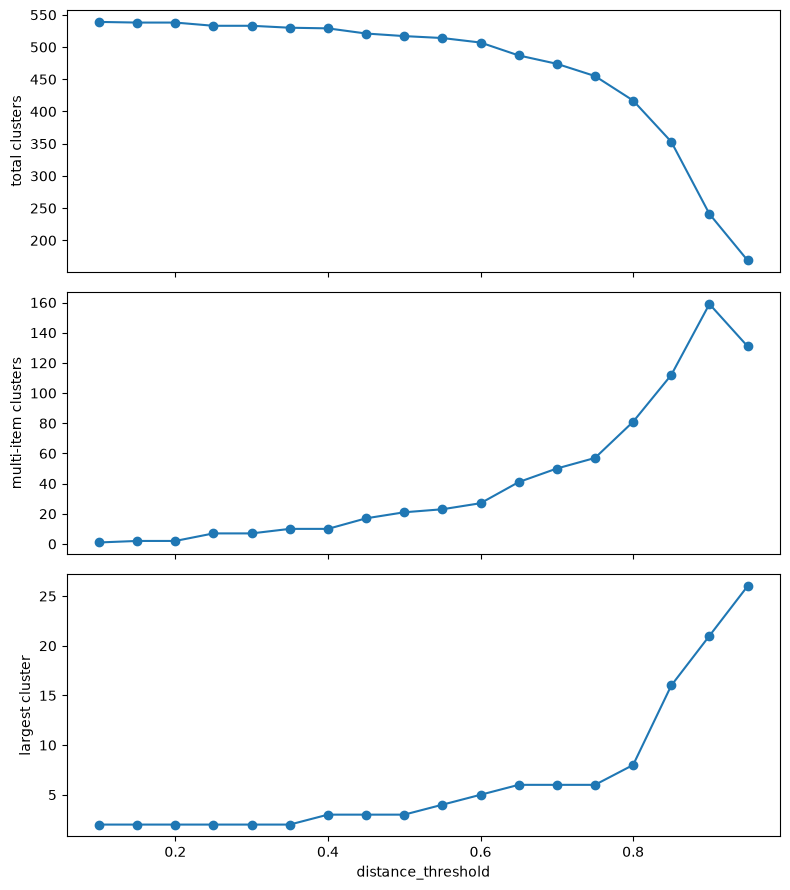

In [ ]:
# precompute the distance matrix ONCE, reuse for every threshold
D = cosine_distances(X.toarray())

thresholds = np.arange(0.1, 1.0, 0.05)
n_clusters = []
n_multi = []          # clusters with >1 item (actual merges)
largest = []          # size of biggest cluster (chaining detector)

for t in thresholds:
    model = AgglomerativeClustering(
        n_clusters=None, distance_threshold=t,
        metric="precomputed", linkage="average",
    )
    labels = model.fit_predict(D)
    sizes = np.bincount(labels)
    n_clusters.append(len(sizes))
    n_multi.append(int((sizes > 1).sum()))
    largest.append(int(sizes.max()))

fig, ax = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
ax[0].plot(thresholds, n_clusters, marker="o"); ax[0].set_ylabel("total clusters")
ax[1].plot(thresholds, n_multi, marker="o");   ax[1].set_ylabel("multi-item clusters")
ax[2].plot(thresholds, largest, marker="o");   ax[2].set_ylabel("largest cluster")
ax[2].set_xlabel("distance_threshold")
plt.tight_layout(); plt.savefig("threshold_sweep.png", dpi=120)


## mini-model embeddings

In [ ]:
# adding new columns to the items table for embeddings and embedding model
con = sqlite3.connect('seed.sqlite')
cursor = con.cursor()

con.execute("ALTER TABLE items ADD COLUMN embedding BLOB")
con.execute("ALTER TABLE items ADD COLUMN embedding_model TEXT")

con.commit()
con.close()

get_table_names()



table results: [('items',), ('sqlite_sequence',), ('item_tags',)]

Table: items
Columns: ['id', 'feed_source', 'url', 'title', 'summary', 'categories', 'published_at', 'fetched_at', 'read', 'note', 'discord_message_id', 'score', 'rank', 'digest_date', 'embedding', 'embedding_model']

Table: sqlite_sequence
Columns: ['name', 'seq']

Table: item_tags
Columns: ['item_id', 'tag']


In [18]:
import numpy as np
from sentence_transformers import SentenceTransformer

item_results = get_titles()

titles = [col[0] for col in item_results]
sources = [col[1] for col in item_results]
summaries = [col[2] for col in item_results]

MODEL_NAME = "all-MiniLM-L6-v2"
BATCH_SIZE = 64


def build_text(title, summary):
    title = title or ""
    summary = summary or ""
    return f"{title}. {title}. {summary}".strip()

def main():
    model = SentenceTransformer(MODEL_NAME)
    con = sqlite3.connect("seed.sqlite")

    rows = con.execute(
        "SELECT id, title, summary FROM items WHERE embedding IS NULL"
    ).fetchall()
    print(f"{len(rows)} items to embed")

    for start in range(0, len(rows), BATCH_SIZE):
        batch = rows[start:start + BATCH_SIZE]
        texts = [build_text(t, s) for _, t, s in batch]

        vecs = model.encode(
            texts,
            normalize_embeddings=True,
            batch_size=BATCH_SIZE,
            show_progress_bar=False,
        ).astype(np.float32)

        con.executemany(
            "UPDATE items SET embedding = ?, embedding_model = ? WHERE id = ?",
            [(v.tobytes(), MODEL_NAME, row[0]) for v, row in zip(vecs, batch)],
        )
        con.commit()
        print(f"  {start + len(batch)}/{len(rows)}")

    con.close()

main()


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1225.34it/s]


2964 items to embed
  64/2964
  128/2964
  192/2964
  256/2964
  320/2964
  384/2964
  448/2964
  512/2964
  576/2964
  640/2964
  704/2964
  768/2964
  832/2964
  896/2964
  960/2964
  1024/2964
  1088/2964
  1152/2964
  1216/2964
  1280/2964
  1344/2964
  1408/2964
  1472/2964
  1536/2964
  1600/2964
  1664/2964
  1728/2964
  1792/2964
  1856/2964
  1920/2964
  1984/2964
  2048/2964
  2112/2964
  2176/2964
  2240/2964
  2304/2964
  2368/2964
  2432/2964
  2496/2964
  2560/2964
  2624/2964
  2688/2964
  2752/2964
  2816/2964
  2880/2964
  2944/2964
  2964/2964


In [16]:
from collections import defaultdict
import umap
import hdbscan
import numpy as np
from sklearn.cluster import AgglomerativeClustering

item_results = get_titles()

titles = [col[0] for col in item_results]
sources = [col[1] for col in item_results]
summaries = [col[2] for col in item_results]
embeddings_list = [np.frombuffer(col[3], dtype=np.float32) for col in item_results]


X = np.vstack(embeddings_list)

# Starting threshold — tune from the sweep. 0.35 is a reasonable first guess
# for normalized MiniLM vectors with cosine + average linkage.
DISTANCE_THRESHOLD = 0.60

clusterer = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=DISTANCE_THRESHOLD,
    metric="cosine",
    linkage="average",
)
labels = clusterer.fit_predict(X)

# Group items by cluster label
clusters = defaultdict(list)
for title, source, label in zip(titles, sources, labels):
    clusters[label].append((title, source))

# Sort clusters by distinct-source count (your corroboration signal), then size
def cluster_key(items):
    distinct_sources = len({s for _, s in items})
    return (-distinct_sources, -len(items))

sorted_clusters = sorted(clusters.values(), key=cluster_key)

print(f"{len(X)} items → {len(clusters)} clusters "
      f"(threshold={DISTANCE_THRESHOLD})")
print()

for i, group in enumerate(sorted_clusters):
    distinct = len({s for _, s in group})
    if len(group) == 1:
        continue  # skip singletons in the printout
    print(f"Cluster {i}: {len(group)} items, {distinct} distinct sources")
    for title, source in group:
        print(f"  - [{source}] {title}")
    print()

540 items → 342 clusters (threshold=0.6)

Cluster 0: 9 items, 9 distinct sources
  - [the_guardian_-_world_news] Derryn Hinch remembered as ‘journalistic James Bond’ – as it happened
  - [foreign_policy] Banning AI Models Doesn’t Add Up to a Policy
  - [the_conversation] Stop policing AI in the classroom, start teaching it
  - [mit_technology_review] China’s AI models have Trump’s AI world at war with itself
  - [gizmodo] The Great Freakout Over Open-Source AI Has Begun
  - [futurism] There’s a Gigantic Problem at the Heart of the AI Industry That Could Cause the Whole Thing to Collapse
  - [the_diplomat] With New AI Governance Organization, China Seeks to Formalize Its Global AI Influence
  - [vox] How public opinion is turning against AI
  - [national_interest] How AI Data Centers Are Reshaping America’s Economy, Politics, and Power Grid

Cluster 1: 17 items, 6 distinct sources
  - [the_guardian_-_world_news] US expands Iran offensive as diplomats claim talks ongoing
  - [al_jazeera]

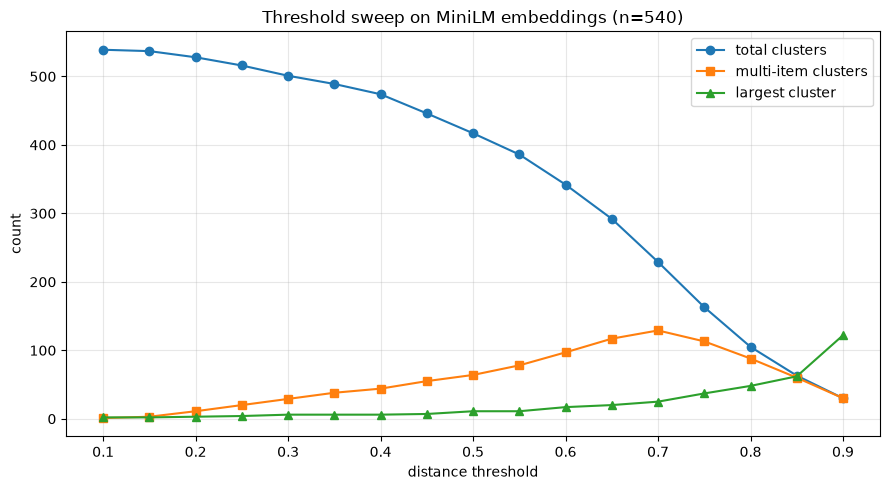

In [13]:
import matplotlib.pyplot as plt

thresholds = np.arange(0.10, 0.95, 0.05)
total_clusters = []
multi_item_clusters = []
largest_cluster = []

for t in thresholds:
    c = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=t,
        metric="cosine",
        linkage="average",
    )
    lbls = c.fit_predict(X)
    sizes = np.bincount(lbls)
    total_clusters.append(len(sizes))
    multi_item_clusters.append(int((sizes > 1).sum()))
    largest_cluster.append(int(sizes.max()))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, total_clusters, label="total clusters", marker="o")
ax.plot(thresholds, multi_item_clusters, label="multi-item clusters", marker="s")
ax.plot(thresholds, largest_cluster, label="largest cluster", marker="^")
ax.set_xlabel("distance threshold")
ax.set_ylabel("count")
ax.set_title(f"Threshold sweep on MiniLM embeddings (n={len(X)})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_sweep_minilm.png", dpi=150)
plt.show()

In [18]:
def item_fit_scores(indices, X):
    """For each item, its mean cosine sim to the OTHER items in the cluster."""
    if len(indices) < 2:
        return {indices[0]: 1.0}
    sub = X[indices]
    sim = sub @ sub.T
    np.fill_diagonal(sim, np.nan)  # exclude self
    means = np.nanmean(sim, axis=1)
    return dict(zip(indices, means))

# Show items that fit poorly in their own cluster
for label, idxs in cluster_indices.items():
    if len(idxs) < 3:
        continue
    fits = item_fit_scores(idxs, X)
    worst = min(fits.values())
    if worst < 0.35:  # tune this
        print(f"Cluster {label} has poor-fit member(s):")
        for i in idxs:
            marker = " ← OUTLIER" if fits[i] < 0.35 else ""
            print(f"  {fits[i]:.3f}  [{sources[i]}] {titles[i]}{marker}")
        print()

Cluster 20 has poor-fit member(s):
  0.514  [al_jazeera] Watch FIFA World Cup: Spain outclass Argentina to become world champions
  0.528  [al_jazeera] Key takeaways from the World Cup 2026 final as Spain beat Argentina
  0.466  [al_jazeera] Photos: Spain beat Argentina to win second World Cup title
  0.396  [al_jazeera] Last night, I was Spanish, and so were millions around the world
  0.334  [al_jazeera] Tearful Scaloni uncertain of Argentina future after World Cup loss ← OUTLIER
  0.446  [al_jazeera] Fans in Madrid party all night long after Spain’s World Cup victory
  0.466  [al_jazeera] Argentinians show pride in Buenos Aires despite World Cup final defeat
  0.532  [al_jazeera] How a young and cohesive Spain took down Lionel Messi’s Argentina
  0.475  [al_jazeera] Palestinians celebrate Spain’s World Cup victory
  0.442  [al_jazeera] Mbappe takes home second Golden Boot, Spain sweeps World Cup awards
  0.515  [al_jazeera] Spain fans hail new generation, as Argentina says goodbye t